# Natural Language Processing. Assignment 1. Tokenization.

In this assignment, you need to implement, train, and analyze a Byte-Pair Encoding (BPE) tokenizer.

The assignment consist of 3 tasks. When you finish all the tasks, create a GitHub repository for this assignment (you can use this repository later for the other assignments) and submit this notebook in the repository. Leave `requirements.txt` file if your code requires additional installations. Submit the link to the repository in Moodle.

## Task 1: Data Preparation and Vocabulary Size Selection (3 points)

First, load the [Brown corpus](https://en.wikipedia.org/wiki/Brown_Corpus). After loading the corpus, you need to select the appropriate vocabulary size for the BPE tokenizer. The appropriate vocabulary size is the minimal vocabulary size that covers at least 90% of the words in the corpus. The coverage is calculated according to the following formula:



$$ \text{coverage}(k) = \frac{\sum_{r=1}^{k} f(r)}{\sum_{r=1}^{N} f(r)} $$



where $f(r)$ is the frequency of the top-$r$ word, $k$ is the number of top-$k$ tokens included in vocab, $N$ is the total unique words in corpus.

So, for this task you need to do the following:

1. Load the Brown corpus (0.5 points)
2. Plot cumulative coverage vs. vocabulary size for the loaded corpus (1 point)
3. Select the appropriate vocabulary size (0.5 point)
4. Answer the questions:
    1. Why the coverage slows down the increase as the vocabulary size increases? (0.5 point)
    2. Which empirical law explains the slowing down increase of the coverage? (0.5 point)

In [2]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Download Brown corpus (only first time)
nltk.download('brown')

from nltk.corpus import brown

[nltk_data] Downloading package brown to
[nltk_data]     /Users/kkorchaginai/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [3]:
# Load words from Brown corpus
words = brown.words()

# Basic preprocessing
words = [word.lower() for word in words if word.isalpha()]

print(f"Total number of word tokens: {len(words)}")
print(f"Number of unique words: {len(set(words))}")

Total number of word tokens: 981716
Number of unique words: 40234


In [4]:
word_freq = Counter(words)

# Sort words by frequency (descending)
sorted_freq = sorted(word_freq.values(), reverse=True)

total_tokens = sum(sorted_freq)

In [5]:
cumulative_freq = np.cumsum(sorted_freq)
coverage = cumulative_freq / total_tokens

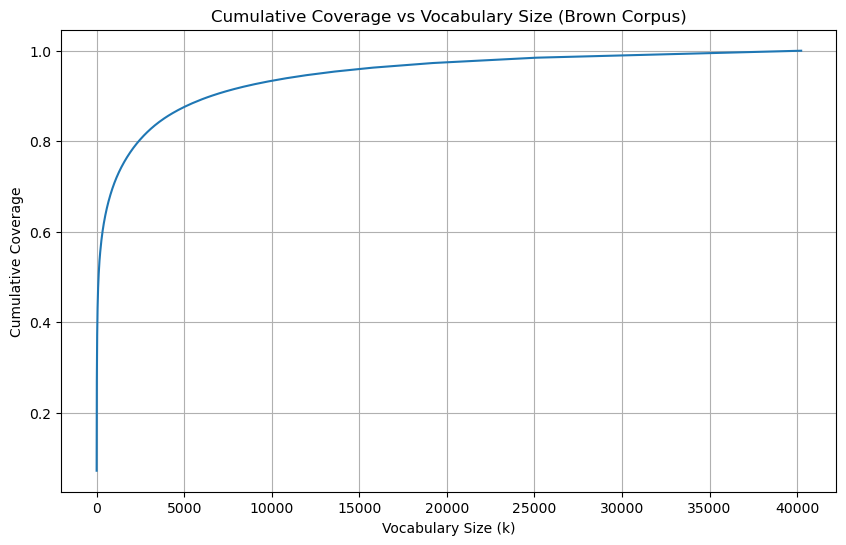

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(coverage)
plt.xlabel("Vocabulary Size (k)")
plt.ylabel("Cumulative Coverage")
plt.title("Cumulative Coverage vs Vocabulary Size (Brown Corpus)")
plt.grid(True)
plt.show()

In [7]:
threshold = 0.9

vocab_size_90 = np.argmax(coverage >= threshold) + 1

print(f"Minimal vocabulary size for ≥90% coverage: {vocab_size_90}")

Minimal vocabulary size for ≥90% coverage: 6545


❓ 1. Why does the coverage growth slow down as vocabulary size increases?

The coverage growth slows down because word frequencies in natural language follow a heavy-tailed distribution. A small number of very frequent words accounts for a large proportion of total word occurrences, while a large number of rare words appear very infrequently. After including the most frequent words, each additional word contributes less and less to the total coverage.

❓ 2. Which empirical law explains this behavior?

This behavior is explained by Zipf’s Law, which states that the frequency of a word is inversely proportional to its rank in the frequency table:

f(r)∝1r
f(r)∝
r
1
	​


According to Zipf’s law, a few words are extremely frequent, and many words are rare, which leads to the slowing growth of cumulative coverage.

## Task 2: Implement Byte-Pair Encoding (BPE) Tokenizer (4 points)

Implement the [BPE tokenizer](https://arxiv.org/pdf/1508.07909) as the `BPETokenizer` class.

The class should contain correctly implemented:

* `train` method (1.5 points).
* `tokenize` method (1.5 points).

The code should have docstrings and comments (1 point).

In [8]:
from collections import defaultdict, Counter
import re


class BPETokenizer:
    """
    Byte-Pair Encoding (BPE) Tokenizer implementation.

    Parameters
    ----------
    vocab_size : int
        Target vocabulary size after training.
    """

    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.vocab = set()
        self.merges = []              # list of merge operations (in order)
        self.token2id = {}
        self.id2token = {}

    def _get_word_frequencies(self, corpus):
        """
        Pre-tokenizes corpus and returns word frequency dictionary.

        Each word is represented as a tuple of characters + '</w>' end symbol.
        """
        word_freq = Counter()

        for sentence in corpus:
            # lowercase and keep only alphabetic tokens
            words = [w.lower() for w in sentence if w.isalpha()]
            for word in words:
                chars = tuple(list(word) + ['</w>'])
                word_freq[chars] += 1

        return word_freq

    def _get_pair_frequencies(self, word_freq):
        """
        Computes frequencies of adjacent symbol pairs.
        """
        pair_freq = defaultdict(int)

        for word, freq in word_freq.items():
            for i in range(len(word) - 1):
                pair = (word[i], word[i + 1])
                pair_freq[pair] += freq

        return pair_freq

    def _merge_pair(self, pair, word_freq):
        """
        Merges the most frequent pair in the vocabulary.
        """
        merged_word_freq = {}

        bigram = re.escape(' '.join(pair))
        pattern = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')

        for word, freq in word_freq.items():
            word_str = ' '.join(word)
            # Replace occurrences of the pair
            new_word = pattern.sub(''.join(pair), word_str)
            merged_word = tuple(new_word.split())
            merged_word_freq[merged_word] = freq

        return merged_word_freq

    def train(self, corpus):
        """
        Trains the BPE tokenizer on the provided corpus.

        Parameters
        ----------
        corpus : list of list of str
            Tokenized sentences (e.g., brown.sents()).
        """
        # Step 1: Get word frequencies
        word_freq = self._get_word_frequencies(corpus)

        # Initialize vocabulary with characters
        for word in word_freq:
            for symbol in word:
                self.vocab.add(symbol)

        # Perform merges until reaching vocab size
        while len(self.vocab) < self.vocab_size:
            pair_freq = self._get_pair_frequencies(word_freq)

            if not pair_freq:
                break

            # Most frequent pair
            best_pair = max(pair_freq, key=pair_freq.get)
            self.merges.append(best_pair)

            # Merge pair
            word_freq = self._merge_pair(best_pair, word_freq)

            # Add new merged token to vocab
            self.vocab.add(''.join(best_pair))

        # Create token-id mappings
        self.token2id = {token: idx for idx, token in enumerate(sorted(self.vocab))}
        self.id2token = {idx: token for token, idx in self.token2id.items()}

    def tokenize(self, sentence):
        """
        Tokenizes a sentence using learned BPE merges.

        Parameters
        ----------
        sentence : list of str
            List of word tokens.

        Returns
        -------
        list of str
            BPE tokenized output.
        """
        output_tokens = []

        for word in sentence:
            if not word.isalpha():
                continue

            word_tokens = list(word.lower()) + ['</w>']

            # Apply merges in order
            for pair in self.merges:
                i = 0
                while i < len(word_tokens) - 1:
                    if (word_tokens[i], word_tokens[i + 1]) == pair:
                        word_tokens[i:i + 2] = [''.join(pair)]
                    else:
                        i += 1

            output_tokens.extend(word_tokens)

        return output_tokens

In [9]:
tokenizer = BPETokenizer(vocab_size=100)
tokenizer.train(brown.sents()[:100])

print(tokenizer.tokenize(["lower", "lowest"]))

['l', 'o', 'w', 'er</w>', 'l', 'o', 'w', 'es', 't</w>']


## Task 3: Tokenizer Training and Analysis (3 points)

1. Train the `BPETokenizer` on the Brown corpus with the appropriate vocabulary size selected in Task 1 (1 points)
2. Use the Brown corpus (1000 samples) to calculate the mean and standard deviation of
    * tokenizer's fertility (1 points)
    * length of the tokenized sentence (1 points)

In [10]:
# Use vocab size from Task 1
vocab_size = 6545

tokenizer = BPETokenizer(vocab_size=vocab_size)

print("Training BPE tokenizer...")
tokenizer.train(brown.sents())

print("Training completed.")
print(f"Final vocabulary size: {len(tokenizer.vocab)}")

Training BPE tokenizer...
Training completed.
Final vocabulary size: 6545


In [11]:
import numpy as np

# Берем 1000 предложений
sentences = brown.sents()[:1000]

fertilities = []
tokenized_lengths = []

for sent in sentences:
    # Только слова (чтобы совпадало с обучением)
    original_words = [w for w in sent if w.isalpha()]
    
    if len(original_words) == 0:
        continue
    
    # Токенизируем
    bpe_tokens = tokenizer.tokenize(sent)
    
    # Fertility
    fertility = len(bpe_tokens) / len(original_words)
    fertilities.append(fertility)
    
    # Длина токенизированного предложения
    tokenized_lengths.append(len(bpe_tokens))

# Среднее и стандартное отклонение
mean_fertility = np.mean(fertilities)
std_fertility = np.std(fertilities)

mean_length = np.mean(tokenized_lengths)
std_length = np.std(tokenized_lengths)

print("Fertility statistics:")
print(f"Mean fertility: {mean_fertility:.4f}")
print(f"Std fertility: {std_fertility:.4f}")

print("\nTokenized sentence length statistics:")
print(f"Mean length: {mean_length:.2f}")
print(f"Std length: {std_length:.2f}")

Fertility statistics:
Mean fertility: 1.2646
Std fertility: 0.2675

Tokenized sentence length statistics:
Mean length: 23.21
Std length: 13.08


## Grading Procedure Details

During the grading of the completed assignments, a random set of students will be sampled for the **offline assignment defence**. The defence will be arranged shortly after the assignment submission deadline. The particular date and time will be announced later. 

The aim of the assignment defence is to ensure the students understand well their own solutions and know how thier solution works. To check this, the students will be asked various questions about the provided solution. In addition, the students will be asked to run their solution to ensure the solution works without errors.

Examples of questions:

1. How the cumulative coverage is calculated? Why is it called cumulative?
2. What is the rank of a word?
3. How does the BPE tokenizer work? Note: for this question, the students will not be able to see the their own implementation.
4. Why do you consider such vocabulary size appropriate?
5. What is the formula for the fertility of the tokenizer?
6. How do you perform pre-tokenization in your implementation?
7. How do you handle stopwords in the training corpus? Why?
8. etc.

As a result of the assignment defence, the grade for the assignment may be adjusted.